In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    recall_score,
)
import seaborn as sns  # For confusion matrix visualization
import os
import requests  # For API submission
import json  # For printing API response

htb_green = "#9fef00"
node_black = "#141d2b"
hacker_grey = "#a4b1cd"
white = "#ffffff"
azure = "#0086ff"  # Class 0
nugget_yellow = "#ffaf00"  # Class 1
malware_red = "#ff3e3e"  # Class 2
vivid_purple = "#9f00ff"  # Class 3
aquamarine = "#2ee7b6"  # Accent

# Plot Style Configuration
plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams.update(
    {
        "figure.facecolor": node_black,
        "axes.facecolor": node_black,
        "axes.edgecolor": hacker_grey,
        "axes.labelcolor": white,
        "text.color": white,
        "xtick.color": hacker_grey,
        "ytick.color": hacker_grey,
        "grid.color": hacker_grey,
        "grid.alpha": 0.1,
        "legend.facecolor": node_black,
        "legend.edgecolor": hacker_grey,
        "legend.frameon": True,
        "legend.labelcolor": white,
        "figure.figsize": (10, 6),
    }
)

# Global seed for reproducibility
SEED = 1337
np.random.seed(SEED)
print(f"Global SEED set to: {SEED}")

# API Configuration
API_EVALUATOR_URL = "http://154.57.164.81:31557/evaluate_model"


Global SEED set to: 1337


In [2]:
print("--- Loading Dataset ---")
dataset_filename = "assessment_dataset.npz"

try:
    data = np.load(dataset_filename)
    X_train_orig = data["X_train"]
    y_train_orig = data["y_train"]  # Keep original labels safe
    X_test = data["X_test"]
    y_test = data["y_test"]
    data.close()
    print(f"Dataset '{dataset_filename}' loaded successfully.")
    print(f"  X_train shape: {X_train_orig.shape}, y_train shape: {y_train_orig.shape}")
    print(f"  X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")
    print(f"  Unique labels in original training data: {np.unique(y_train_orig)}")
    print(f"  Original training label distribution: {np.bincount(y_train_orig)}")
except FileNotFoundError:
    print(
        f"ERROR: Dataset file '{dataset_filename}' not found. Please ensure it's in the correct location."
    )
    X_train_orig, y_train_orig, X_test, y_test = [
        None
    ] * 4  # Ensure variables exist but are None
except Exception as e:
    print(f"ERROR: Could not load dataset. {e}")
    X_train_orig, y_train_orig, X_test, y_test = [None] * 4

if X_train_orig is None:
    print("CRITICAL ERROR: Dataset not loaded. Cannot proceed with the assessment.")

--- Loading Dataset ---
Dataset 'assessment_dataset.npz' loaded successfully.
  X_train shape: (1500, 2), y_train shape: (1500,)
  X_test shape: (500, 2), y_test shape: (500,)
  Unique labels in original training data: [0 1 2 3]
  Original training label distribution: [375 375 375 375]



--- Data Exploration ---


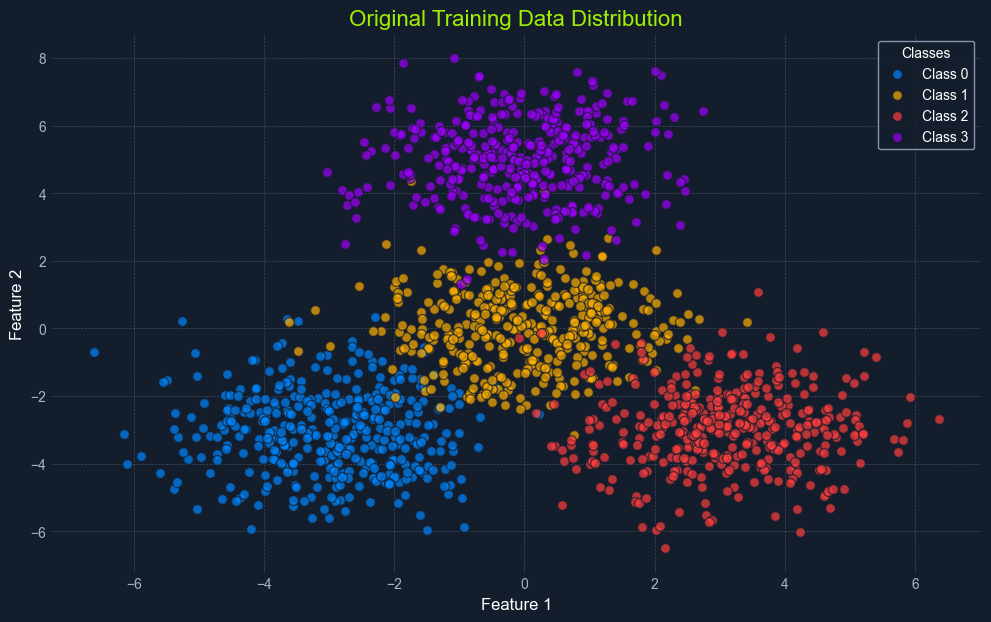

In [3]:
print("\n--- Data Exploration ---")

# Define colors
class_colors_map_viz = {
    0: azure,  # Class 0
    1: nugget_yellow,  # Class 1
    2: malware_red,  # Class 2
    3: vivid_purple,  # Class 3
}


def plot_dataset_points(X, y, title="Dataset Visualization"):
    """Plots the 2D dataset with class-specific colors."""
    if X is None or y is None:
        print(f"Cannot plot: Data for '{title}' is missing.")
        return

    plt.figure(figsize=(12, 7))
    unique_labels = np.unique(y)

    for label_val in unique_labels:
        label_val = int(label_val)  # Ensure it's an int for dictionary key
        plt.scatter(
            X[y == label_val, 0],
            X[y == label_val, 1],
            color=class_colors_map_viz.get(label_val, hacker_grey),  # Fallback color
            label=f"Class {label_val}",
            edgecolors=node_black,
            s=50,
            alpha=0.7,
        )

    plt.title(title, fontsize=16, color=htb_green)
    plt.xlabel("Feature 1", fontsize=12)
    plt.ylabel("Feature 2", fontsize=12)
    if unique_labels.size > 0:  # Only show legend if there are labels
        plt.legend(title="Classes")
    plt.grid(True, color=hacker_grey, linestyle="--", linewidth=0.5, alpha=0.3)
    plt.show()


if X_train_orig is not None:
    plot_dataset_points(
        X_train_orig, y_train_orig, title="Original Training Data Distribution"
    )
else:
    print("Skipping data visualization as data was not loaded.")



--- Training Baseline Model ---
Training baseline OvR Logistic Regression model...
Baseline model trained successfully.

Baseline Model Performance on Clean Test Set:
  Overall Accuracy: 0.9260

Classification Report (Baseline Model):
              precision    recall  f1-score   support

     Class 0       0.92      0.99      0.95       125
     Class 1       0.96      0.74      0.83       125
     Class 2       0.90      0.98      0.94       125
     Class 3       0.93      0.99      0.96       125

    accuracy                           0.93       500
   macro avg       0.93      0.93      0.92       500
weighted avg       0.93      0.93      0.92       500



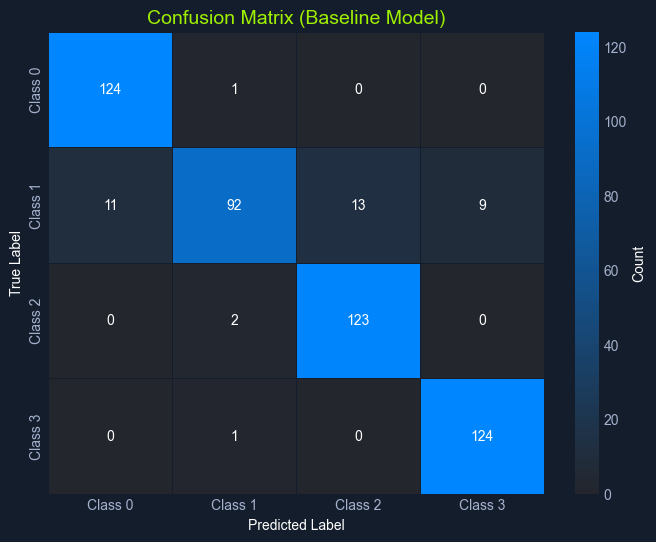

In [4]:
# Train an OvR Logistic Regression classifier on the original training data.
print("\n--- Training Baseline Model ---")
baseline_model = None
baseline_accuracy = 0.0

if X_train_orig is not None:
    # Define the base estimator (Logistic Regression)
    #######
    ### Don't change these parameters! The API will expect them as is,
    #######
    base_estimator_config = {
        "random_state": SEED,
        "solver": "liblinear",
        "C": 1.0,
        "max_iter": 200,
    }

    baseline_logistic_estimator = LogisticRegression(**base_estimator_config)
    baseline_model = OneVsRestClassifier(baseline_logistic_estimator)

    print("Training baseline OvR Logistic Regression model...")
    baseline_model.fit(X_train_orig, y_train_orig)
    print("Baseline model trained successfully.")

    # Evaluate baseline model on the clean test set
    y_pred_baseline = baseline_model.predict(X_test)
    baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
    print(f"\nBaseline Model Performance on Clean Test Set:")
    print(f"  Overall Accuracy: {baseline_accuracy:.4f}")

    # Detailed report
    num_classes = len(np.unique(y_train_orig))
    target_names_report = [f"Class {i}" for i in range(num_classes)]
    print("\nClassification Report (Baseline Model):")
    print(
        classification_report(
            y_test, y_pred_baseline, target_names=target_names_report, zero_division=0
        )
    )

    # Confusion Matrix for Baseline
    cm_baseline = confusion_matrix(
        y_test, y_pred_baseline, labels=np.arange(num_classes)
    )
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm_baseline,
        annot=True,
        fmt="d",
        cmap=sns.dark_palette(azure, as_cmap=True),
        xticklabels=target_names_report,
        yticklabels=target_names_report,
        cbar_kws={"label": "Count"},
        linecolor=node_black,
        linewidths=0.5,
    )
    plt.title("Confusion Matrix (Baseline Model)", fontsize=14, color=htb_green)
    plt.ylabel("True Label", color=white)
    plt.xlabel("Predicted Label", color=white)
    plt.show()
else:
    print("Skipping baseline model training as data was not loaded.")



Label distribution in original y_train:      [375 375 375 375]
Label distribution in y_train_poisoned:  [450 225 450 375]


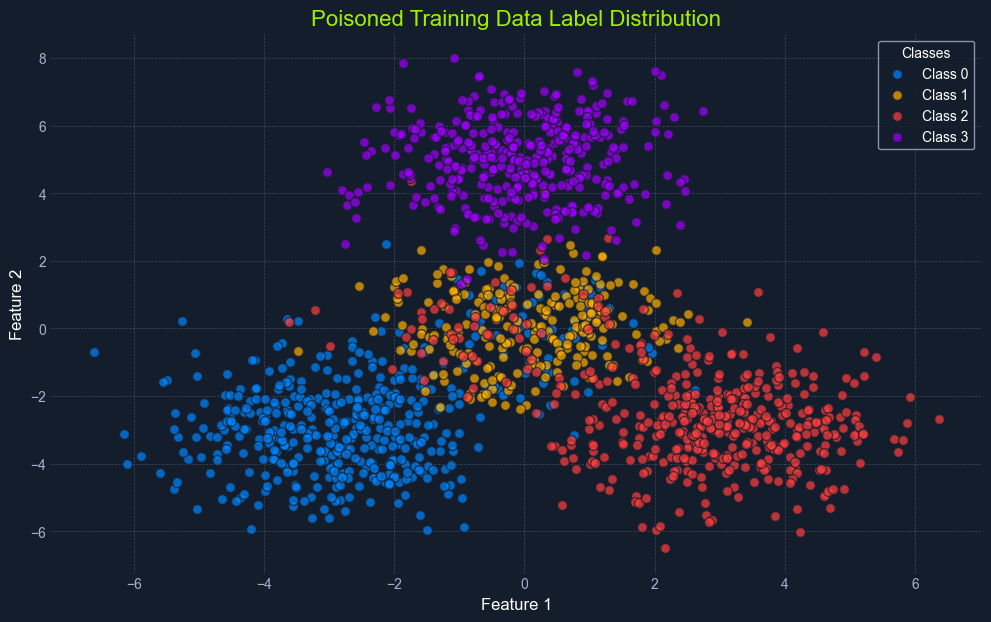

In [7]:
# Implement your attack strategy here.

y_train_poisoned = None  # Initialize

if y_train_orig is not None:
    y_train_poisoned = y_train_orig.copy()

    class1_indices = np.where(y_train_orig == 1)[0]
    
    shuffled_class1 = class1_indices.copy()
    np.random.default_rng(SEED).shuffle(shuffled_class1)

    n_to_flip = int(len(class1_indices) * 0.4)
    flip_indices = shuffled_class1[:n_to_flip]

    half = len(flip_indices) // 2
    flip_to_0 = flip_indices[:half]
    flip_to_2 = flip_indices[half:]

    y_train_poisoned[flip_to_0] = 0
    y_train_poisoned[flip_to_2] = 2

    # Verify the changes
    print(f"\nLabel distribution in original y_train:      {np.bincount(y_train_orig)}")
    if y_train_poisoned is not None:
        print(
            f"Label distribution in y_train_poisoned:  {np.bincount(y_train_poisoned)}"
        )
        plot_dataset_points(
            X_train_orig,
            y_train_poisoned,
            title="Poisoned Training Data Label Distribution",
        )
else:
    print("Skipping attack implementation as original training data was not loaded.")



--- Training Poisoned Model ---
Training poisoned OvR Logistic Regression model...
Poisoned model trained successfully.

Poisoned Model Performance on Clean Test Set:
  Overall Accuracy: 0.7760
  (Baseline Accuracy was: 0.9260)

Classification Report (Poisoned Model):
              precision    recall  f1-score   support

     Class 0       0.74      1.00      0.85       125
     Class 1       1.00      0.12      0.21       125
     Class 2       0.68      0.99      0.81       125
     Class 3       0.93      0.99      0.96       125

    accuracy                           0.78       500
   macro avg       0.84      0.78      0.71       500
weighted avg       0.84      0.78      0.71       500



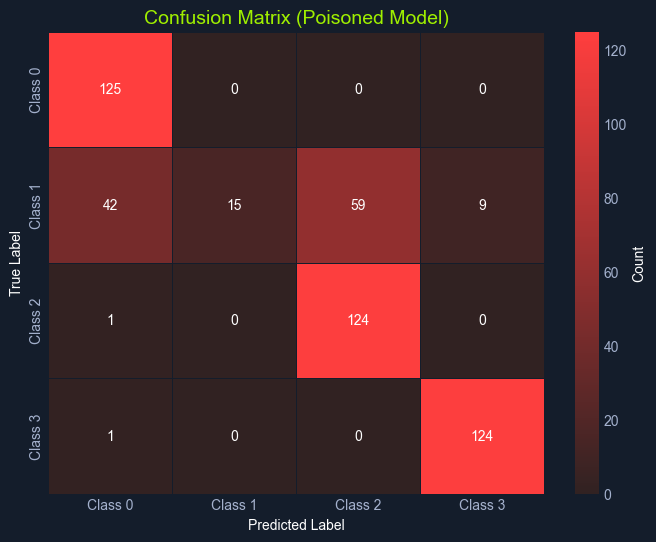


Analysis of Class 1 predictions by Poisoned Model (on local test set):
  Total Class 1 test samples: 125
  Predicted as Class 0: 42 (33.60%)
  Predicted as Class 1 (Correct): 15 (12.00%)
  Predicted as Class 2: 59 (47.20%)
  Predicted as Class 3: 9 (7.20%)
  Recall for Class 3 (Poisoned Model): 0.9920


In [8]:
print("\n--- Training Poisoned Model ---")
poisoned_model = None  # Initialize

if X_train_orig is not None and y_train_poisoned is not None:
    # Use the same configuration for the logistic regression estimator
    poisoned_logistic_estimator = LogisticRegression(**base_estimator_config)
    poisoned_model = OneVsRestClassifier(poisoned_logistic_estimator)

    print("Training poisoned OvR Logistic Regression model...")
    poisoned_model.fit(
        X_train_orig, y_train_poisoned
    )  # Use X_train_orig and y_train_poisoned
    print("Poisoned model trained successfully.")

    # Evaluate your poisoned model on the clean test set
    print("\nPoisoned Model Performance on Clean Test Set:")
    y_pred_poisoned = poisoned_model.predict(X_test)
    poisoned_accuracy = accuracy_score(y_test, y_pred_poisoned)
    print(f"  Overall Accuracy: {poisoned_accuracy:.4f}")
    if baseline_model is not None:  # Check if baseline_accuracy was computed
        print(f"  (Baseline Accuracy was: {baseline_accuracy:.4f})")

    print("\nClassification Report (Poisoned Model):")
    print(
        classification_report(
            y_test, y_pred_poisoned, target_names=target_names_report, zero_division=0
        )
    )

    # Confusion Matrix for Poisoned Model
    cm_poisoned = confusion_matrix(
        y_test, y_pred_poisoned, labels=np.arange(num_classes)
    )
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm_poisoned,
        annot=True,
        fmt="d",
        cmap=sns.dark_palette(malware_red, as_cmap=True),
        xticklabels=target_names_report,
        yticklabels=target_names_report,
        cbar_kws={"label": "Count"},
        linecolor=node_black,
        linewidths=0.5,
    )
    plt.title("Confusion Matrix (Poisoned Model)", fontsize=14, color=htb_green)
    plt.ylabel("True Label", color=white)
    plt.xlabel("Predicted Label", color=white)
    plt.show()

    # Detailed check for Class 1 misclassification (as per assessment objective)
    class1_actual_indices_test = np.where(y_test == 1)[0]
    if len(class1_actual_indices_test) > 0:
        class1_predictions_poisoned_model = y_pred_poisoned[class1_actual_indices_test]

        misclassified_as_0 = np.sum(class1_predictions_poisoned_model == 0)
        misclassified_as_2 = np.sum(class1_predictions_poisoned_model == 2)
        correctly_as_1 = np.sum(class1_predictions_poisoned_model == 1)
        misclassified_as_3 = np.sum(class1_predictions_poisoned_model == 3)
        total_class1_test = len(class1_actual_indices_test)

        print(
            f"\nAnalysis of Class 1 predictions by Poisoned Model (on local test set):"
        )
        print(f"  Total Class 1 test samples: {total_class1_test}")
        print(
            f"  Predicted as Class 0: {misclassified_as_0} ({misclassified_as_0 / total_class1_test * 100:.2f}%)"
        )
        print(
            f"  Predicted as Class 1 (Correct): {correctly_as_1} ({correctly_as_1 / total_class1_test * 100:.2f}%)"
        )
        print(
            f"  Predicted as Class 2: {misclassified_as_2} ({misclassified_as_2 / total_class1_test * 100:.2f}%)"
        )
        print(
            f"  Predicted as Class 3: {misclassified_as_3} ({misclassified_as_3 / total_class1_test * 100:.2f}%)"
        )

        # Check Class 3 Recall
        class3_recall_poisoned = recall_score(
            y_test, y_pred_poisoned, labels=[3], average="macro", zero_division=0
        )
        print(f"  Recall for Class 3 (Poisoned Model): {class3_recall_poisoned:.4f}")
    else:
        print("No Class 1 samples in the local test set to analyze for ambiguity.")
else:
    print(
        "Skipping poisoned model training as data was not loaded or attack not implemented."
    )


In [9]:
print("\n--- Saving Poisoned Model Parameters ---")
output_model_filename = "poisoned_model_params.npz"

if poisoned_model is not None:
    try:
        params_to_save = {}
        # Ensure the model was fitted and has estimators
        if not hasattr(poisoned_model, "estimators_"):
            raise AttributeError(
                "Poisoned model does not have 'estimators_' attribute. Was it trained?"
            )

        for i, estimator in enumerate(poisoned_model.estimators_):
            if not hasattr(estimator, "coef_") or not hasattr(estimator, "intercept_"):
                raise AttributeError(
                    f"Estimator {i} is not fitted or does not have coef_/intercept_."
                )
            params_to_save[f"coef_estimator_{i}"] = estimator.coef_
            params_to_save[f"intercept_estimator_{i}"] = estimator.intercept_

        if not hasattr(poisoned_model, "classes_"):
            raise AttributeError("Poisoned model does not have 'classes_' attribute.")
        params_to_save["classes_"] = poisoned_model.classes_

        np.savez_compressed(output_model_filename, **params_to_save)
        print(f"Poisoned model parameters saved to '{output_model_filename}'.")
        print("This is the file you should submit to the evaluation API.")
    except AttributeError as ae:
        print(
            f"Error saving parameters: Model or its estimators might not be fully trained or accessible. Details: {ae}"
        )
    except Exception as e:
        print(
            f"An unexpected error occurred while saving poisoned model parameters: {e}"
        )
else:
    print("Poisoned model not available. Skipping model parameter saving.")



--- Saving Poisoned Model Parameters ---
Poisoned model parameters saved to 'poisoned_model_params.npz'.
This is the file you should submit to the evaluation API.


In [10]:
print("\n--- Submitting Model to API for Evaluation ---")

if os.path.exists(output_model_filename):
    print(f"Found '{output_model_filename}' for submission.")
    try:
        with open(output_model_filename, "rb") as f:
            files = {
                "model_params": (output_model_filename, f, "application/octet-stream")
            }

            print(f"Submitting to: {API_EVALUATOR_URL}")
            response = requests.post(
                API_EVALUATOR_URL, files=files, timeout=30
            )  # Added timeout

            print("\n--- API Response ---")
            print(f"Status Code: {response.status_code}")
            try:
                response_json = response.json()
                print(json.dumps(response_json, indent=2))  # Pretty print JSON
                if response_json.get("attack_successful", False):
                    print(
                        f"\nSUCCESS! Flag: {response_json.get('flag', 'No flag in response.')}"
                    )
                else:
                    print(
                        "\nAttack did not meet all criteria or an error occurred. Check API response details."
                    )
            except requests.exceptions.JSONDecodeError:
                print("Response from API was not in JSON format:")
                print(response.text)

    except requests.exceptions.ConnectionError:
        print(f"CONNECTION ERROR: Could not connect to the API at {API_EVALUATOR_URL}.")
        print("Please ensure your spawned instance is is running and accessible.")
    except FileNotFoundError:
        print(
            f"ERROR: File '{output_model_filename}' not found for submission, even though it should exist."
        )
    except Exception as e:
        print(f"An unexpected error occurred during API submission: {e}")
        # traceback.print_exc() # For more detailed debugging if needed
else:
    print(f"Model parameter file '{output_model_filename}' not found. Cannot submit.")



--- Submitting Model to API for Evaluation ---
Found 'poisoned_model_params.npz' for submission.
Submitting to: http://154.57.164.81:31557/evaluate_model

--- API Response ---
Status Code: 200
{
  "attack_successful": true,
  "criteria_met": {
    "class1_to_class0_ambiguity": true,
    "class1_to_class2_ambiguity": true,
    "class3_recall_maintained": true
  },
  "evaluation_status": "complete",
  "flag": "HTB{4mbiguity_m4st3r}",
  "message": "Attack successful! Ambiguity achieved and constraints met.",
  "metrics": {
    "class1_correctly_as_1": 15,
    "class1_misclassified_as_0": 42,
    "class1_misclassified_as_0_percent": 0.336,
    "class1_misclassified_as_2": 59,
    "class1_misclassified_as_2_percent": 0.472,
    "class1_misclassified_as_3": 9,
    "class1_total_samples": 125,
    "class3_precision": 0.9323308270676691,
    "class3_recall": 0.992,
    "overall_accuracy": 0.776
  }
}

SUCCESS! Flag: HTB{4mbiguity_m4st3r}
